In [ ]:
import pandas as pd
import numpy as np

# **basic**

In [ ]:
from google.colab import files
files.upload()

Saving train_passenger_survival.csv to train_passenger_survival (1).csv


{'train_passenger_survival (1).csv': b'PassengerID,Age,Gender,SeatClass,Fare,Survived\n1,27,Female,Second,43.45,0\n2,11,Male,Second,45.05,1\n3,55,Female,Third,22.28,0\n4,60,Male,First,80.77,0\n5,18,Male,First,122.85,1\n6,72,Male,Third,36.68,0\n7,21,Female,Third,10.65,1\n8,32,Male,Second,46.25,1\n9,34,Male,Second,78.11,1\n10,67,Male,Third,38.54,0\n11,44,Male,Second,49.24,0\n12,35,Male,First,125.37,1\n13,74,Male,Second,76.23,1\n14,59,Male,Second,75.66,0\n15,27,Male,First,87.92,1\n16,15,Male,First,83.63,1\n17,53,Female,Second,43.62,1\n18,48,Male,First,122.32,1\n19,49,Male,Second,66.09,1\n20,10,Male,Second,57.75,0\n21,26,Female,Second,78.64,1\n22,53,Female,Second,60.47,1\n23,12,Male,First,129.33,1\n24,42,Male,First,145.68,1\n25,46,Female,Second,47.13,1\n26,65,Female,Third,35.87,0\n27,48,Male,First,119.54,1\n28,55,Female,Second,46.31,0\n29,39,Male,First,98.33,1\n30,37,Male,Third,10.75,0\n31,29,Male,Third,12.04,1\n32,80,Female,Second,47.31,0\n33,48,Female,Third,23.66,1\n34,28,Female,First,14

In [ ]:
df = pd.read_csv('train_passenger_survival.csv')
df.head(2)


,PassengerID,Age,Gender,SeatClass,Fare,Survived
0,1,27,Female,Second,43.45,0
1,2,11,Male,Second,45.05,1


In [ ]:

df.columns

Index(['PassengerID', 'Age', 'Gender', 'SeatClass', 'Fare', 'Survived'], dtype='object')

In [ ]:
df.shape

(70, 6)

In [ ]:
df.isnull().sum()

,0
PassengerID,0
Age,0
Gender,0
SeatClass,0
Fare,0
Survived,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70 entries, 0 to 69
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerID  70 non-null     int64  
 1   Age          70 non-null     int64  
 2   Gender       70 non-null     object 
 3   SeatClass    70 non-null     object 
 4   Fare         70 non-null     float64
 5   Survived     70 non-null     int64  
dtypes: float64(1), int64(3), object(2)
memory usage: 3.4+ KB


In [ ]:
df.describe()

,PassengerID,Age,Fare,Survived
count,70.000000,70.000000,70.000000,70.000000
mean,35.500000,40.971429,63.233143,0.628571
std,20.351085,20.849336,39.011102,0.486675
min,1.000000,10.000000,10.650000,0.000000
25%,18.250000,23.250000,36.140000,0.000000
50%,35.500000,42.000000,52.975000,1.000000
75%,52.750000,56.500000,82.915000,1.000000
max,70.000000,80.000000,148.240000,1.000000


In [ ]:
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
numerical_cols = df.select_dtypes(include=['int']).columns.tolist()
print("\nCategorical Columns:", categorical_cols)
print("Numerical Columns:", numerical_cols)


Categorical Columns: ['Gender', 'SeatClass']
Numerical Columns: ['PassengerID', 'Age', 'Survived']


In [ ]:
for col in categorical_cols:
    print(f"{col}: {df[col].nunique()} unique values -> {df[col].unique()[:10]}")


Gender: 2 unique values -> ['Female' 'Male']
SeatClass: 3 unique values -> ['Second' 'Third' 'First']


In [ ]:
df['Survived'].value_counts()



,count
Survived,
1,44
0,26


In [ ]:
df.groupby('Survived')['Age'].mean()


,Age
Survived,
0,46.0
1,38.0


In [ ]:
df.groupby('Survived')['Fare'].mean()

,Fare
Survived,
0,44.740385
1,74.160682


In [ ]:
df.groupby('Gender')['Survived'].mean()


,Survived
Gender,
Female,0.620690
Male,0.634146


In [ ]:
df.groupby('SeatClass')['Survived'].mean()

,Survived
SeatClass,
First,0.894737
Second,0.600000
Third,0.428571


In [ ]:
df.groupby('SeatClass')['Gender'].value_counts()

SeatClass  Gender
First      Male      15
           Female     4
Second     Male      16
           Female    14
Third      Female    11
           Male      10
Name: count, dtype: int64

# **visualization**

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

<Axes: xlabel='Gender', ylabel='count'>

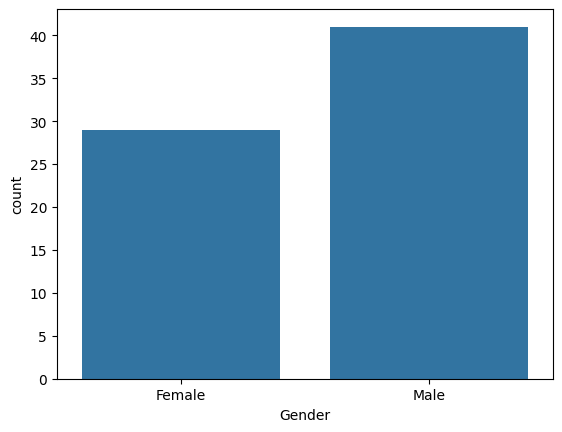

In [ ]:
sns.countplot(data=df, x='Gender')

<Axes: xlabel='SeatClass', ylabel='count'>

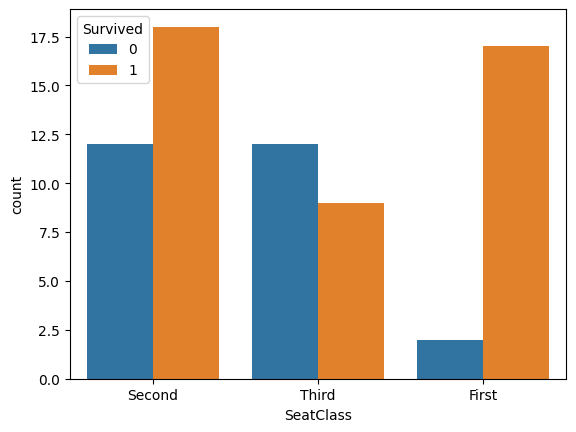

In [ ]:
sns.countplot(data=df, x='SeatClass',hue='Survived')

<Axes: xlabel='Gender', ylabel='Fare'>

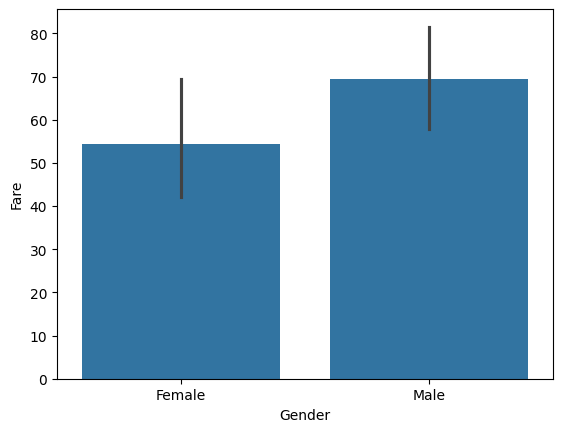

In [ ]:
sns.barplot(data=df, x='Gender',y='Fare')

<Axes: xlabel='SeatClass', ylabel='Age'>

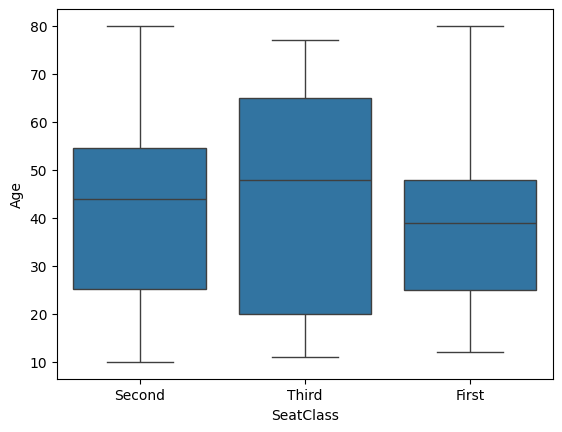

In [ ]:
sns.boxplot(data=df, x='SeatClass', y='Age')


<Axes: xlabel='SeatClass', ylabel='Age'>

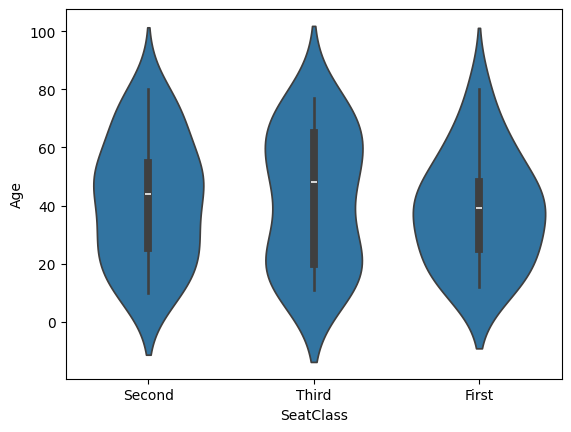

In [ ]:
sns.violinplot(data=df, x='SeatClass', y='Age')


<Axes: xlabel='Age', ylabel='Count'>

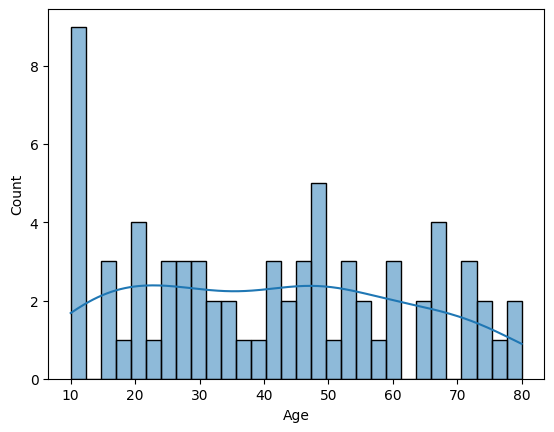

In [ ]:
sns.histplot(data=df,x='Age',bins=30,kde=True)

<Axes: xlabel='Age', ylabel='Fare'>

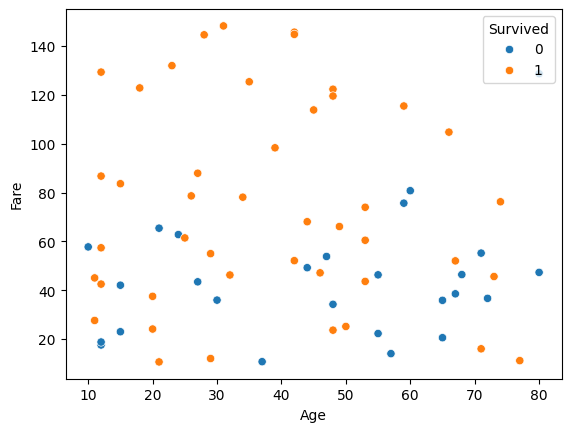

In [ ]:
sns.scatterplot(data=df, x='Age', y='Fare', hue='Survived')


In [ ]:
df.columns

Index(['PassengerID', 'Age', 'Gender', 'SeatClass', 'Fare', 'Survived'], dtype='object')

/tmp/ipython-input-3545567608.py:1: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(data=df['Age'], shade=True)


<Axes: xlabel='Age', ylabel='Density'>

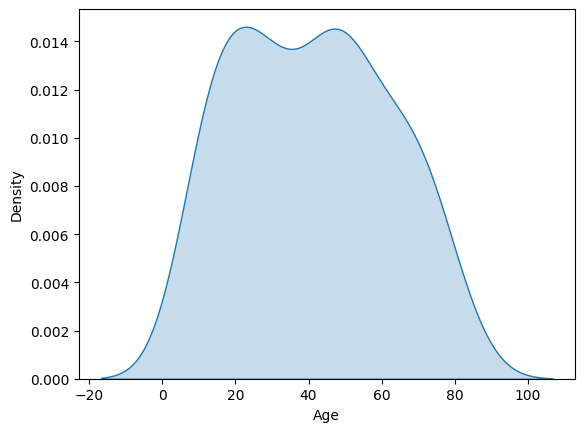

In [ ]:
sns.kdeplot(data=df['Age'], shade=True)


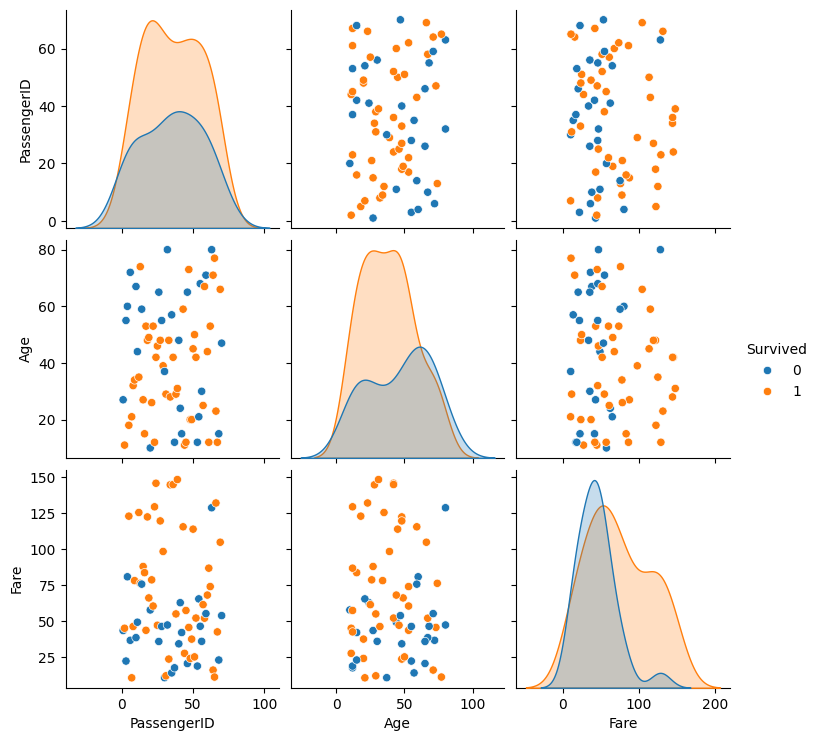

In [ ]:
sns.pairplot(df, hue='Survived')


In [ ]:
sns.set_style("whitegrid")   # options: white, dark, ticks, whitegrid, darkgrid
sns.set_palette("pastel")    # color themes


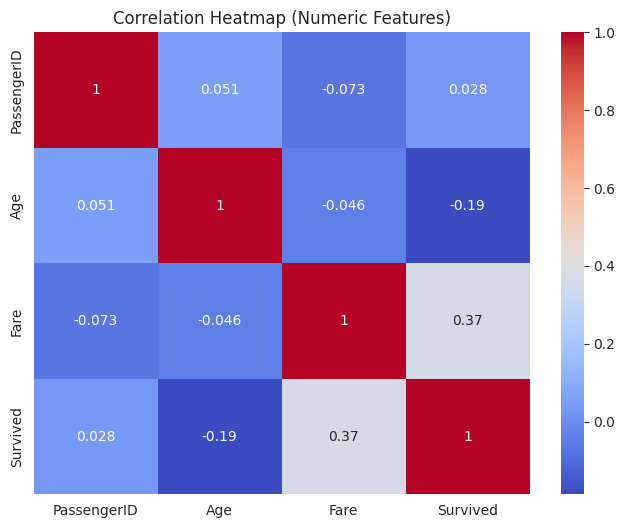

In [ ]:
# Select only numeric columns
numeric_df = df.select_dtypes(include=['int64', 'float64'])

# Correlation heatmap
plt.figure(figsize=(8,6))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap (Numeric Features)")
plt.show()




In [ ]:
import matplotlib.pyplot as plt

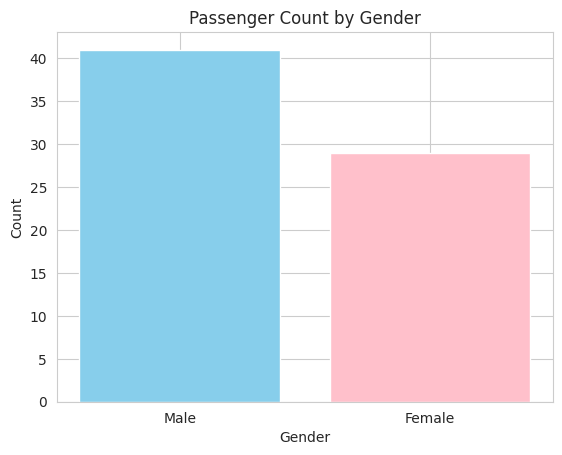

In [ ]:
import matplotlib.pyplot as plt

gender_counts = df['Gender'].value_counts()

plt.bar(gender_counts.index, gender_counts.values, color=["skyblue", "pink"])
plt.title("Passenger Count by Gender")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.show()


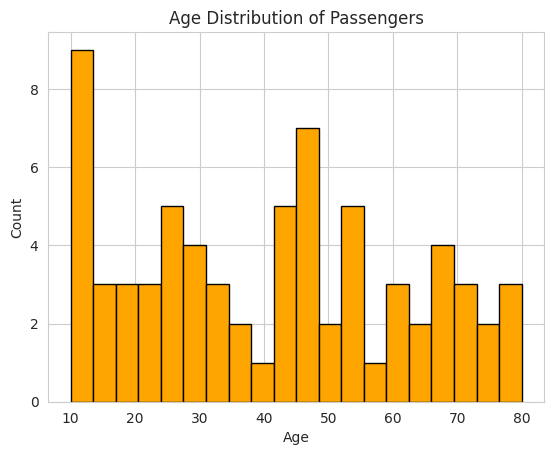

In [ ]:
plt.hist(df['Age'].dropna(), bins=20, color="orange", edgecolor="black")
plt.title("Age Distribution of Passengers")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()


In [ ]:
print("Before:", df.shape)
df_temp = df.drop(['Gender'], axis=1)
print("After dropping 'Name':", df_temp.shape)

# row example
print("Before:", df.shape)
df_temp2 = df.drop([0], axis=0)
print("After dropping row 0:", df_temp2.shape)


Before: (70, 6)
After dropping 'Name': (70, 5)
Before: (70, 6)
After dropping row 0: (69, 6)


In [ ]:
df1=df[['Age','Fare']].sum(axis=1).head()
df1.head()


,0
0,70.45
1,56.05
2,77.28
3,140.77
4,140.85


In [ ]:
from sklearn.model_selection import train_test_split

X=df.drop(['PassengerID','Survived'],axis=1)
y=df['Survived']
X_train, X_test, y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

model = LogisticRegression(max_iter=1000)  # max_iter prevents convergence warnings
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.6428571428571429


# **ENCODING**
label for output ,ohe for nominal ,oe for order

In [ ]:
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OrdinalEncoder

In [ ]:
df = pd.read_csv('train_passenger_survival.csv')
oe = OrdinalEncoder(categories=[['Third','Second','First']])
df[['SeatClass']] = oe.fit_transform(df[['SeatClass']])
df.head()

,PassengerID,Age,Gender,SeatClass,Fare,Survived
0,1,27,Female,1.0,43.45,0
1,2,11,Male,1.0,45.05,1
2,3,55,Female,0.0,22.28,0
3,4,60,Male,2.0,80.77,0
4,5,18,Male,2.0,122.85,1


onehotencoding in two ways

In [ ]:
df = pd.get_dummies(df, columns=['Gender'], drop_first=True, dtype=int)
df.head()

,PassengerID,Age,SeatClass,Fare,Survived,Gender_Male
0,1,27,1.0,43.45,0,0
1,2,11,1.0,45.05,1,1
2,3,55,0.0,22.28,0,0
3,4,60,2.0,80.77,0,1
4,5,18,2.0,122.85,1,1


In [ ]:
from sklearn.preprocessing import OneHotEncoder
oe = OneHotEncoder(sparse_output=False, drop=None)
gender_encoded = oe.fit_transform(df[['Gender']])
gender_df = pd.DataFrame(gender_encoded, columns=oe.get_feature_names_out(['Gender']))
df = pd.concat([df.drop(columns=['Gender']), gender_df], axis=1)

df = pd.get_dummies(df, columns=['SeatClass'], dtype=int)
df.head()


,PassengerID,Age,Fare,Survived,Gender_Female,Gender_Male,SeatClass_0.0,SeatClass_1.0,SeatClass_2.0
0,1,27,43.45,0,1.0,0.0,0,1,0
1,2,11,45.05,1,0.0,1.0,0,1,0
2,3,55,22.28,0,1.0,0.0,1,0,0
3,4,60,80.77,0,0.0,1.0,0,0,1
4,5,18,122.85,1,0.0,1.0,0,0,1


In [ ]:
from sklearn.model_selection import train_test_split
X=df.drop(['PassengerID','Survived'],axis=1)
y=df['Survived']
X_train, X_test, y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))


Accuracy: 0.6428571428571429


# **pipeline**

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
X = df.drop(['Survived','PassengerID'], axis=1)
y = df['Survived']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
num_features = ['Age', 'Fare']         # numerical → scale
cat_features = ['Gender', 'SeatClass'] # categorical → encode
preprocessor = ColumnTransformer(transformers=[('num', StandardScaler(), num_features),('cat', OneHotEncoder(drop='first'), cat_features)])
pipe = Pipeline([('preprocessing', preprocessor),('model', LogisticRegression(max_iter=1000))])
pipe.fit(X_train, y_train)
accuracy = pipe.score(X_test, y_test)
print("Pipeline Accuracy:", accuracy)





**TYPES OF** **SCALING**

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(df[['Age','Fare']]) #know standard deviation and mean values
df[['Age', 'Fare']] = scaler.transform(df[['Age', 'Fare']])
df[['Age', 'Fare']] = scaler.transform(df[['Age', 'Fare']])
print("Train Means:\n", df[['Age','Fare']].mean().round(4))
print("Train STDs:\n", df[['Age','Fare']].std(ddof=0).round(4))
df.head()


In [ ]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
df[['Age',"Fare"]] = scaler.fit_transform(df[['Age',"Fare"]])
print("min value",df[['Age','Fare']].min())
print("max value",df[['Age','Fare']].max())
df.head()

In [ ]:
from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()
df[['Age', 'Fare']] = scaler.fit_transform(df[['Age', 'Fare']])

print("Median after scaling:\n", df[['Age','Fare']].median())
print("IQR effect (Q1, Q3):\n", df[['Age','Fare']].quantile([0.25,0.75]))
df.head()


In [ ]:
from sklearn.preprocessing import Normalizer

scaler = Normalizer()
df[['Age', 'Fare']] = scaler.fit_transform(df[['Age', 'Fare']])
df.head()


In [ ]:
from sklearn.preprocessing import MaxAbsScaler

scaler = MaxAbsScaler()
df[['Age', 'Fare']] = scaler.fit_transform(df[['Age', 'Fare']])
print("Max Abs Values:\n", df[['Age','Fare']].max())
df.head()


In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
df = pd.read_csv("train_passenger_survival.csv")
X = df.drop(["Survived","PassengerID"], axis=1)
y = df["Survived"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
def test_scaler(scaler, X_train, X_test, y_train, y_test):
    cols = ['Age','Fare']
    X_train_scaled = X_train.copy()
    X_test_scaled = X_test.copy()

    X_train_scaled[cols] = scaler.fit_transform(X_train[cols])
    X_test_scaled[cols] = scaler.transform(X_test[cols])
    model = LogisticRegression(max_iter=1000)
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    return accuracy_score(y_test, y_pred)
results = {}
results["No Scaling"] = test_scaler(StandardScaler().fit([[0,1]]), X_train, X_test, y_train, y_test)
results["StandardScaler"] = test_scaler(StandardScaler(), X_train, X_test, y_train, y_test)
results["MinMaxScaler"] = test_scaler(MinMaxScaler(), X_train, X_test, y_train, y_test)
results["RobustScaler"] = test_scaler(RobustScaler(), X_train, X_test, y_train, y_test)
results["Normalizer"] = test_scaler(Normalizer(), X_train, X_test, y_train, y_test)
results["MaxAbsScaler"] = test_scaler(MaxAbsScaler(), X_train, X_test, y_train, y_test)
print(results)


# **DECISION TREE**

In [ ]:
X = df.drop(["Survived", "PassengerID"], axis=1)
y = df["Survived"]
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
dt = DecisionTreeClassifier(max_depth = 6,random_state=42)
dt.fit(X_train, y_train)
y_test = dt.predict(X_test)
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred))



Decision Tree Accuracy: 0.7142857142857143


In [ ]:
dt = DecisionTreeClassifier(
    max_depth=4,       # limit tree depth
    min_samples_split=10, # minimum samples to split a node
    min_samples_leaf=5,   # minimum samples at a leaf
    criterion="gini"      # or "entropy"
)
dt.fit(X_train, y_train)


y_pred = dt.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))


Accuracy: 0.8571428571428571


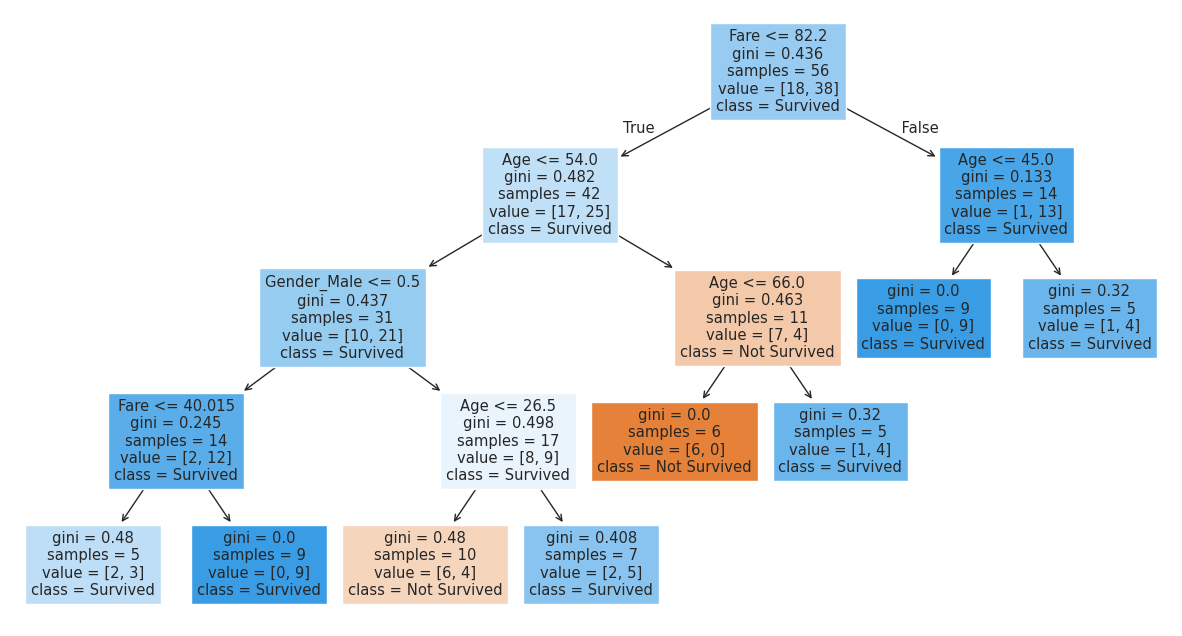

In [ ]:
from sklearn import tree
import matplotlib.pyplot as plt

plt.figure(figsize=(15,8))
tree.plot_tree(dt, feature_names=X_train.columns, class_names=["Not Survived","Survived"], filled=True)
plt.show()

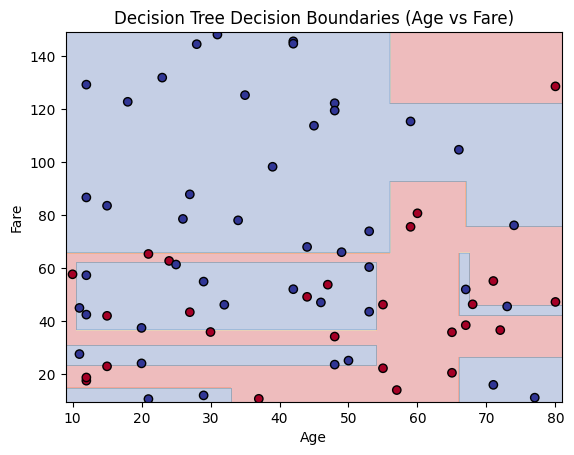

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.tree import DecisionTreeClassifier
import pandas as pd

# Assuming df is already loaded and contains the data

# Select features and target
# Exclude non-numeric columns and 'PassengerID'
X = df.drop(['PassengerID', 'Survived'], axis=1)
y = df['Survived']

# Perform one-hot encoding on categorical features
X = pd.get_dummies(X, columns=['Gender', 'SeatClass'], drop_first=True, dtype=int)


# Train Decision Tree
clf = DecisionTreeClassifier(max_depth=3, random_state=42)
clf.fit(X, y)

# To plot decision boundaries, we need to select two numerical features after encoding.
# Let's select 'Age' and 'Fare' for visualization purposes.
# If you want to visualize other pairs of features, you can change them here.
X_plot = X[['Age', 'Fare']].values
y_plot = y.values


# Create a meshgrid for plotting decision regions
x_min, x_max = X_plot[:, 0].min() - 1, X_plot[:, 0].max() + 1
y_min, y_max = X_plot[:, 1].min() - 1, X_plot[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),
                     np.arange(y_min, y_max, 0.1))

# Predict on the meshgrid. We need to make sure the meshgrid has the same number of features as the trained model.
# Since we trained the model on all encoded features, we need to create a dummy dataframe
# with the same columns as X, fill the 'Age' and 'Fare' columns with meshgrid values,
# and fill other columns with their mean or a representative value (e.g., 0 for one-hot encoded features).
# A simpler approach for visualization is to retrain a model on only the two features used for plotting.

# Retrain the model on the two selected features for plotting
clf_plot = DecisionTreeClassifier(max_depth=7, random_state=42)
clf_plot.fit(X_plot, y_plot)

Z = clf_plot.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot decision boundaries
plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.RdYlBu)
plt.scatter(X_plot[:, 0], X_plot[:, 1], c=y_plot, edgecolor='k', cmap=plt.cm.RdYlBu)
plt.xlabel("Age") # Updated label
plt.ylabel("Fare") # Updated label
plt.title("Decision Tree Decision Boundaries (Age vs Fare)") # Updated title
plt.show()

In [ ]:
from sklearn.datasets import load_iris
import pandas as pd

iris = load_iris()
df_iris = pd.DataFrame(data=iris.data, columns=iris.feature_names)
df_iris['target'] = iris.target

X = df_iris[['petal length (cm)', 'petal width (cm)']]
y = df_iris['target']

# KNN

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
X=df.drop(['PassengerID','Survived'],axis=1)
y=df['Survived']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
knn = KNeighborsClassifier(n_neighbors=4)  # K = 3
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.7857142857142857


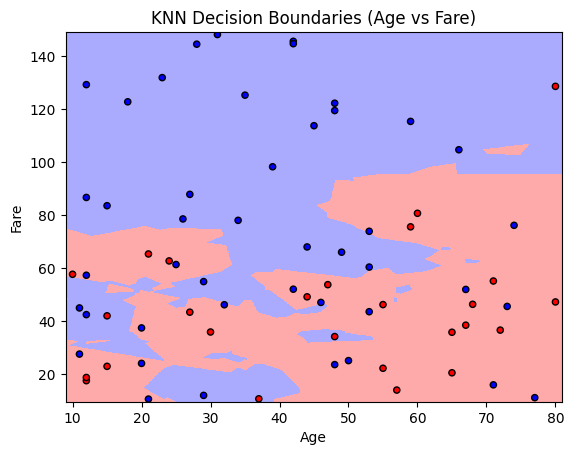

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

# Select 'Age' and 'Fare' for visualization
X_plot = X[['Age', 'Fare']].values
y_plot = y.values

# Create color maps
cmap_light = ListedColormap(['#FFAAAA', '#AAFFAA', '#AAAAFF'])
cmap_bold = ListedColormap(['#FF0000', '#00FF00', '#0000FF'])

# Fit the KNN model on the selected features
knn_plot = KNeighborsClassifier(n_neighbors=4)
knn_plot.fit(X_plot, y_plot)

# Plot the decision boundary. For that, we will assign a color to each
# point in the mesh [x_min, x_max]x[y_min, y_max].
x_min, x_max = X_plot[:, 0].min() - 1, X_plot[:, 0].max() + 1
y_min, y_max = X_plot[:, 1].min() - 1, X_plot[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),
                     np.arange(y_min, y_max, 0.1))
Z = knn_plot.predict(np.c_[xx.ravel(), yy.ravel()])

# Put the result into a color plot
Z = Z.reshape(xx.shape)
plt.figure()
plt.pcolormesh(xx, yy, Z, cmap=cmap_light)

# Plot also the training points
plt.scatter(X_plot[:, 0], X_plot[:, 1], c=y_plot, cmap=cmap_bold,
            edgecolor='k', s=20)
plt.xlim(xx.min(), xx.max())
plt.ylim(yy.min(), yy.max())
plt.title("KNN Decision Boundaries (Age vs Fare)")
plt.xlabel("Age")
plt.ylabel("Fare")
plt.show()